In [ ]:
#1: import prereq libraries
import numpy as np
import pandas as pd
import seaborn as sns
import os
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import pingouin as pg


import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap

# Set the aesthetic style of the plots
sns.set_style("whitegrid")





In [3]:
# Extra Functions

#corr matrix -- found online
def pearsoncorrelationmatrix(df):
    
    #Calculates the correlation matrix and p-values for a Pandas DataFrame.

    #Args:
        #df (pd.DataFrame): The input DataFrame.

    #Returns:
        #tuple: A tuple containing two Pandas DataFrames:
            #- Correlation matrix
            #- P-value matrix

    #count for size of tables
    n = df.shape[1]
    #initialize matrices
    corr_matrix = np.zeros((n, n))
    p_matrix = np.zeros((n, n))

    #Loop: calculate correlation coefficient and p value for n x n 
    for i in range(n):

        for j in range(n):

            #calculate values for each 
            corr, p = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
            corr_matrix[i, j] = corr
            p_matrix[i, j] = p

    #create a df from the matrix to be used for indexing values
    corr_df = pd.DataFrame(corr_matrix, columns=df.columns, index=df.columns)
    p_df = pd.DataFrame(p_matrix, columns=df.columns, index=df.columns)
    return corr_df, p_df






# Function to clean the REDCap data, based on the features that we need
def redcap_clean(df_raw, measures_we_care_about):


    #some feature engineering to extract the data we care about

    # Find MADRS sum
    madrs = ['madrs1', 'madrs2', 'madrs3', 'madrs4', 'madrs5', 'madrs6', 'madrs7', 'madrs8', 'madrs9', 'madrs10']
    # Find CUPIT sum
    cupit = ['q1_cupit', 'q2_cupit', 'q3_cupit', 'q4_cupit', 'q5_cupit', 'q6_cupit', 'q7_cupit', 'q8_cupit', 'q9_cupit', 'q10_cupit', 'q11_cupit', 'q12_cupit', 'q13_cupit', 'q14_cupit', 'q15_cupit', 'q16_cupit']
    #find TEPS sum
    teps  = ['tep_q1', 'teps_q2', 'teps_q3', 'teps_4', 'teps_q5', 'teps_q6', 'teps_q7', 'teps_q8', 'teps_q9', 'teps_q10', 'tep_q11', 'teps_q12', 'teps_q13', 'teps_q14', 'teps_q15', 'teps_q16', 'teps_q17', 'teps_q18']
    
    #Anticipatory- 1, 3, 7, 11, 12, 14, 15, 16, 17, 18
    tepsa = ['tep_q1', 'teps_q3', 'teps_q7', 'tep_q11', 'teps_q12', 'teps_q14', 'teps_q15', 'teps_q16', 'teps_q17', 'teps_q18']
    tepsc = [item for item in teps if item not in tepsa]

    #find ra values
    ra_values = ['ra_1', 'ra_2', 'ra_3', 'ra_4', 'ra_5', 'ra_6', 'ra_7', 'ra_8', 'ra_9', 'ra_10',
             'ra_11', 'ra_12', 'ra_13', 'ra_14', 'ra_15', 'ra_16', 'ra_17', 'ra_18', 'ra_19',
             'ra_20', 'ra_21', 'ra_22', 'ra_23', 'ra_24', 'ra_25', 'ra_26', 'ra_27', 'ra_28',
             'ra_29', 'ra_30', 'ra_31', 'ra_32', 'ra_33', 'ra_34', 'ra_35', 'ra_36', 'ra_37',
             'ra_38', 'ra_39', 'ra_40', 'ra_41', 'ra_42', 'ra_43']


    #find pain catastrophizing scale values
    pc_values = ['pc_2', 'pc_3', 'pc_4', 'pc_5', 'pc_6', 'pc_7', 'pc_8', 'pc_9', 'pc_10', 'pc_11', 'pc_12', 'pc_13', 'pc_14']


    #find ucla item values
    ucla_val  = ['q1', 'q2', 'q3']
    
    #find anxiety item values
    #anxiety   = ['imp','can','sca','me','stay','beat','stomach','sick','heart','short','upset','unable','feel','body','worry','am']
    anxiety    = ['asi1', 'asi2', 'asi3', 'asi4', 'asi5', 'asi6', 'asi7', 'asi8', 'asi9', 'asi10', 'asi11', 'asi12', 'asi13', 'asi14', 'asi15', 'asi16']


    #turn 6 dimensional race matrix into 1 dimension
    races = ['race___1','race___2','race___3','race___4','race___5','race___6']

    #create a DFAQ score
    dfaq  = ['dfaq_q6_28dd01','dfaq_q7_b08ee6']

    #sum up the values for each of the mental health measures
    df_raw['madrs']     = df_raw[madrs].sum(axis=1)
    df_raw['cupit']     = df_raw[cupit].sum(axis=1)
    df_raw['teps']      = df_raw[teps].sum(axis=1)
    df_raw['teps_a']    = df_raw[tepsa].sum(axis=1)
    df_raw['teps_c']    = df_raw[tepsc].sum(axis=1)
    df_raw['ira']       = df_raw[ra_values].sum(axis=1)
    df_raw['ucla']      = df_raw[ucla_val].sum(axis=1)
    df_raw['anxiety']   = df_raw[anxiety].sum(axis=1)
    df_raw['pc']        = df_raw[pc_values].sum(axis=1)
    df_raw['race']      = df_raw[races].idxmax(axis=1).str.replace('race___', '')
    df_raw['DFAQ']      = df_raw[dfaq].sum(axis=1)
    df_raw['sex']       = df_raw['ed3']
    df_raw['thc']       = df_raw['delta_9_thc']


    #return the cleaned df with the measures we need
    df = df_raw[measures_we_care_about]

    return df;



In [6]:
#3: Read Einstein Redcap 

#initialize file path, load spreadsheet
files = 'RedcapAbstract/ecomRedcapUSETHIS.csv'
df_dirty = pd.read_csv(files)

#ID the measures that we care about
col_we_care_about = ['record_id','age','race', 'pc','cupit','bdi_score','teps']

#clean einstein data using dirty dataset and measures we care about
df_ecom = redcap_clean(df_dirty, col_we_care_about)



/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/1386326886.py:95: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError


In [7]:
#4:Read ePain dataset -- to merge with Einstein data

#initialize file path
files = 'RedcapAbstract/ePrime_F_extractedUSETHIS.csv'
df_epain = pd.read_csv(files)

#drop any unnecessary columns; since this isnt clinical information we will merge it with the ecom data based on id
col_we_care_about = ['id','mock_detect', 'mock_pain','mock_max']
df_epain = df_epain[col_we_care_about]

# merge epain data with ecom data on id, drop duplicate id column
df_epain = df_epain.merge(df_ecom, left_on='id', right_on='record_id', how='inner')
df_epain = df_epain.drop(columns=['record_id'])

# Drop duplicate rows based on 'id' column -- we only want baseline visit
df_epain = df_epain.drop_duplicates(subset=['id'])

#change the max pain from >10 to 11 -- since >10 prevents us from converting to numeric
df_epain['mock_max'] = df_epain['mock_max'].replace('>10', 11)
df_epain['mock_pain'] = df_epain['mock_pain'].replace('>10', 11)

#convert to numeric
df_epain['mock_max'] = pd.to_numeric(df_epain['mock_max'], errors='coerce')
df_epain['mock_pain'] = pd.to_numeric(df_epain['mock_pain'], errors='coerce')



_______________________________Pearson R Correlations___________________________________
PEARSON R CORRELATION: Is mock max correlated with mock pain?
Pearson r: 0.9396945580756064, p-value: 6.093052465493217e-07

PEARSON R CORRELATION: Is bdi correlated with mock pain?
Pearson r: -0.1941000905605918, p-value: 0.506105750458091

PEARSON R CORRELATION: Is teps correlated with mock pain?
Pearson r: -0.14800307915316568, p-value: 0.61359948810083

PEARSON R CORRELATION: Is teps correlated with mock max?
Pearson r: -0.034717190819844757, p-value: 0.9062079953133525



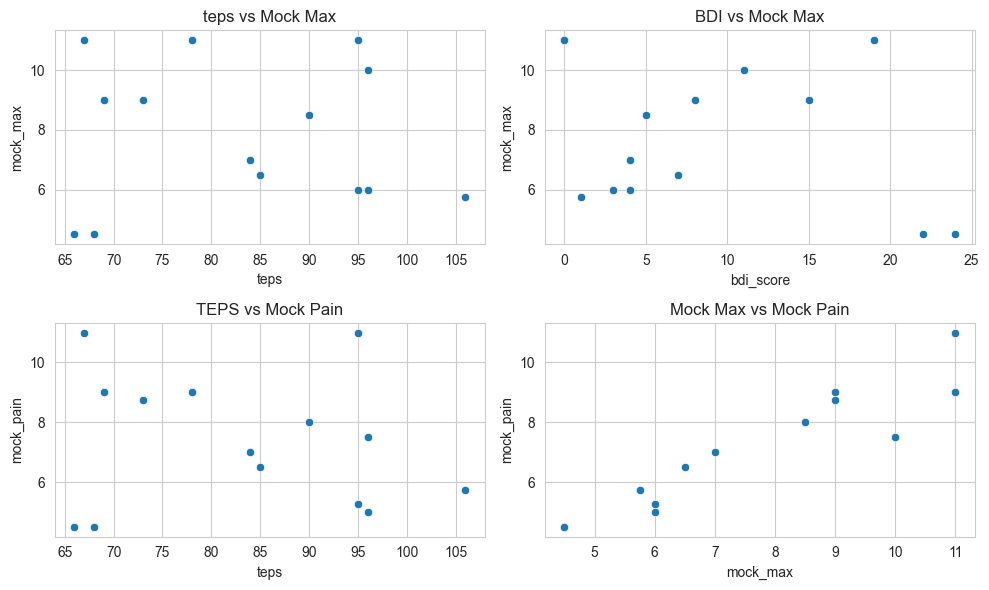

_______________________________Mediation Analyses___________________________________
2: Mediating analysis: mock max, BDI and CUPIT
            path      coef        se      pval  CI[2.5%]  CI[97.5%] sig
0  bdi_score ~ X -0.157857  0.285056  0.589902 -0.778940   0.463226  No
1  Y ~ bdi_score -0.267057  0.278191  0.356010 -0.873182   0.339068  No
2          Total  0.148715  0.285465  0.611876 -0.473261   0.770690  No
3         Direct  0.109281  0.292399  0.715702 -0.534286   0.752848  No
4       Indirect  0.039434  0.119939  0.904000 -0.074254   0.495483  No
____________________________________________________________________________________
3: Mediating analysis: Epain Threshold, BDI and CUPIT
            path      coef        se      pval  CI[2.5%]  CI[97.5%] sig
0  bdi_score ~ X -0.157857  0.285056  0.589902 -0.778940   0.463226  No
1  Y ~ bdi_score -0.194100  0.283185  0.506106 -0.811107   0.422907  No
2          Total  0.151359  0.285349  0.605488 -0.470364   0.773082  No
3        

In [11]:
#5: EPAIN: EINSTEIN Run some basic stats on the data

#Pulling Pearson R values and p-values -- At primary investigator's discretion 
#Must account for multiple comparisons -- Typically with Bonferroni correction

print('_______________________________Pearson R Correlations___________________________________')

#DEPENDENTS: Are mock max and mock pain correlated?
print('PEARSON R CORRELATION: Is mock max correlated with mock pain?')
pearson_r, p_value = stats.pearsonr(df_epain['mock_max'], df_epain['mock_pain'])
print(f"Pearson r: {pearson_r}, p-value: {p_value}\n")

#INDEPENDENT vs DEPENDENT: Are bdi and teps correlated with mock max and mock pain?
print('PEARSON R CORRELATION: Is bdi correlated with mock pain?')
pearson_r, p_value = stats.pearsonr(df_epain['bdi_score'], df_epain['mock_pain'])
print(f"Pearson r: {pearson_r}, p-value: {p_value}\n")

print('PEARSON R CORRELATION: Is teps correlated with mock pain?')
pearson_r, p_value = stats.pearsonr(df_epain['teps'], df_epain['mock_pain'])   
print(f"Pearson r: {pearson_r}, p-value: {p_value}\n")

print('PEARSON R CORRELATION: Is teps correlated with mock max?')
pearson_r, p_value = stats.pearsonr(df_epain['teps'], df_epain['mock_max'])
print(f"Pearson r: {pearson_r}, p-value: {p_value}\n")


#plot a scatterplot to visualize the relationship for each variable
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
sns.scatterplot(x='teps', y='mock_max', data=df_epain)
plt.title('teps vs Mock Max')
plt.subplot(2, 2, 2)
sns.scatterplot(x='bdi_score', y='mock_max', data=df_epain)
plt.title('BDI vs Mock Max')
plt.subplot(2, 2, 3)
sns.scatterplot(x='teps', y='mock_pain', data=df_epain)
plt.title('TEPS vs Mock Pain')
plt.subplot(2, 2, 4)
sns.scatterplot(x='mock_max', y='mock_pain', data=df_epain)
plt.title('Mock Max vs Mock Pain')
plt.tight_layout()
plt.show()


print('_______________________________Mediation Analyses___________________________________')

print('2: Mediating analysis: mock max, BDI and CUPIT')
measures = ['mock_max','bdi_score','cupit']
mediationmatrix  = df_epain[measures].dropna()

#scale the data
scaler = StandardScaler()

mediationmatrix = pd.DataFrame(scaler.fit_transform(mediationmatrix), columns=mediationmatrix.columns)

#add a constant
mediationmatrix = sm.add_constant(mediationmatrix)

# Mediation analysis: hiv -> bdi_score -> pc
mediation_results = pg.mediation_analysis(data=mediationmatrix, x='cupit', m='bdi_score', y='mock_max')

# Display the results
print(mediation_results)



print('____________________________________________________________________________________')


print('3: Mediating analysis: Epain Threshold, BDI and CUPIT')
measures = ['mock_pain','bdi_score','cupit']
mediationmatrix  = df_epain[measures].dropna()

mediationmatrix = pd.DataFrame(scaler.fit_transform(mediationmatrix), columns=mediationmatrix.columns)

#add a constant
mediationmatrix = sm.add_constant(mediationmatrix)

# Mediation analysis: hiv -> bdi_score -> pc
mediation_results = pg.mediation_analysis(data=mediationmatrix, x='cupit', m='bdi_score', y='mock_pain')

# Display the results
print(mediation_results)



In [13]:
# 6: Read Miami Redcap

#initialize the data path
files = 'RedcapAbstract/HIV.3.4.csv'
df_dirty = pd.read_csv(files)

#choose the measures we care about
#measures_we_care_about = ['record_id','age','race','ethnicity','hiv_status', 'madrs', 'madrs10', 'bdi_q4', 'bdi_q9', 'bdi_q12', 'bdi_q21', 'bdi_score', 'teps' , 'shaps_totalscore','cupit', 'total_scale_sc', 'ira','ucla','pc','pegoverallscore','DFAQ','anxiety']

#for the ENTIRE Dataset
measures_we_care_about = ['record_id','sex', 'age','race','ethnicity', 'hiv_status','pc','pegoverallscore', 'madrs', 'bdi_score', 'ucla','ira', 'total_scale_sc', 'cupit','anxiety','DFAQ','teps' ,'shaps_totalscore','wbc','hematocrit','thyroid_stimulating_hormone','cd4_cd8_ratio']

#clean the data
df_miami_clean = redcap_clean(df_dirty, measures_we_care_about)

#delete the first 7 rows, omit test/sample rows
df_miami_clean = df_miami_clean.iloc[8:151 , :]

#replace any spaces in ID with nothing -- so we can identify which studies each participant is in (B,C,D)
df_miami_clean['record_id'] = df_miami_clean['record_id'].str.replace(' ', '')
#capitalize any characters for indexing
df_miami_clean['record_id'] = df_miami_clean['record_id'].str.upper()

#locate any UM participants that are dropped out from the study
dropout = ['BD2010','BD2002','BD2009','BD2008','BD2016','BD2041','BCD2026','BD2029','BD2011','BCD2048','BD2057','BCD2081','BD2060','BCD2051','BCD2044','BCD2007','BCD2091','BCD2097','BCD2073','BD2074','BD2059','BD2129','BCD2107','BD2082','BCD2070','BD2017','C2138','BD2069','C2095','BCD2128','BD2126','BCD2147','BD2119','BCD2154','BCD2079','BD2121','C2151','BD2122','BCD2145','BD2093','BCD2156','BCD2160','BCD2136','BCD2034','C2006','BCD2166']
df_um = df_miami_clean[~df_miami_clean['record_id'].isin(dropout)]



#separate the data into the CANDIE and MIND; based on ID name

#filter for candie participants
df_um_candie = df_um[df_um['record_id'].str.contains('C')]
df_um_candie = df_um_candie.drop_duplicates(subset='record_id')

#filter for mind participants
df_um_mind = df_um[df_um['record_id'].str.contains('D')]
df_um_mind = df_um_mind.drop_duplicates(subset='record_id')
#df_um_mind = df_um.dropna()

#all clean!


/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/1386326886.py:95: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError


_______________________________VIF Analysis___________________________________
                        Feature       VIF
0                           age  2.773850
1                    hiv_status  3.937335
2                            pc  2.213102
3               pegoverallscore  1.966043
4                         madrs  4.385542
5                     bdi_score  3.827018
6                         cupit  2.202927
7                          DFAQ  1.538882
8                          teps  1.473872
9              shaps_totalscore  1.409828
10                          wbc  1.336798
11                   hematocrit  1.361373
12  thyroid_stimulating_hormone  1.355842
13                cd4_cd8_ratio  2.308532
_______________________________Correlation Matrix___________________________________


/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_85625/2350825585.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


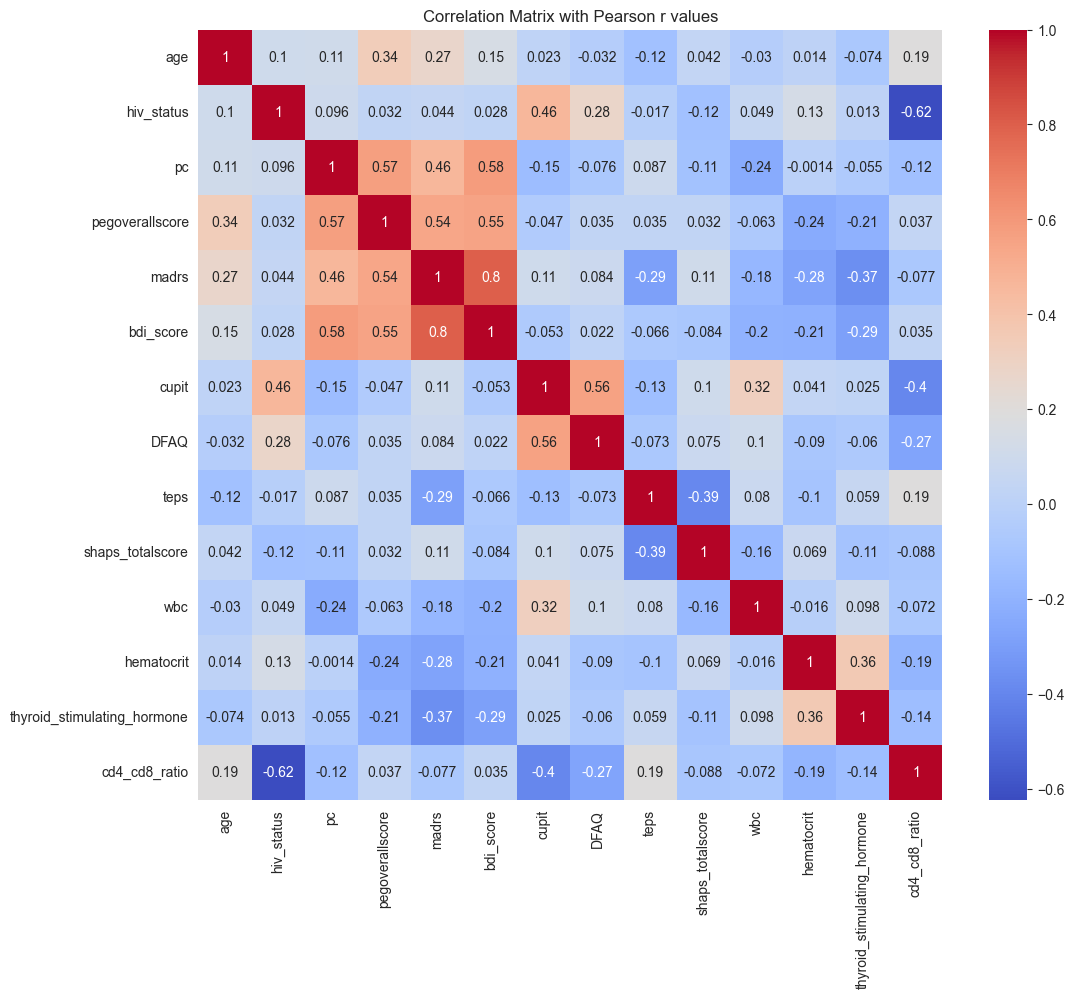

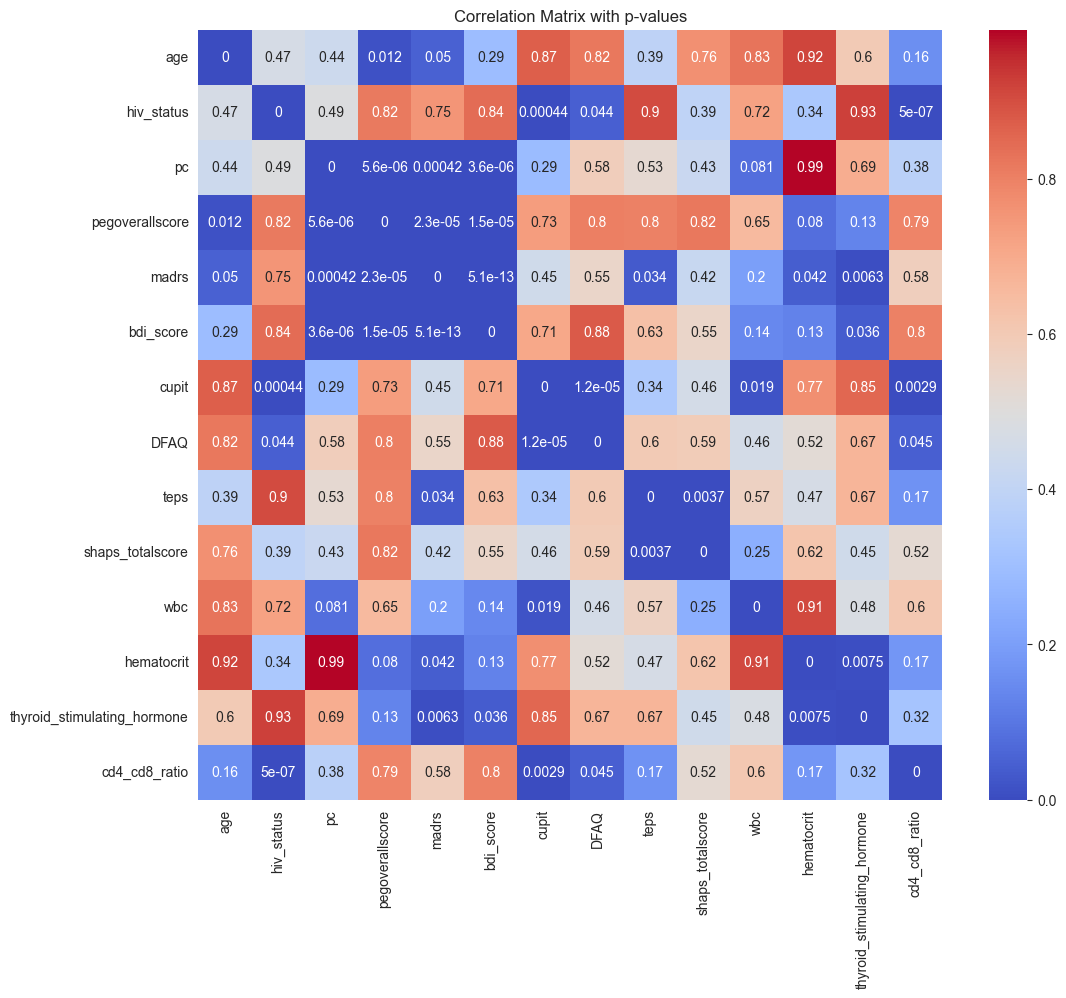

_______________________________PCA Analysis___________________________________
Explained variance ratio: [0.9246749  0.01815726]
PCA components:
 [[ 0.99900374  0.00405948  0.00916568  0.02834901  0.02246214  0.0124092
   0.00187031 -0.00263309 -0.00993374  0.00349038 -0.00260376  0.00106634
  -0.00624258  0.01614464]
 [-0.03451281 -0.00176121  0.41227474  0.40700172  0.48555737  0.5105848
  -0.06103944  0.02128273 -0.04327936  0.00912544 -0.18340307 -0.23239414
  -0.26953146 -0.01720568]]


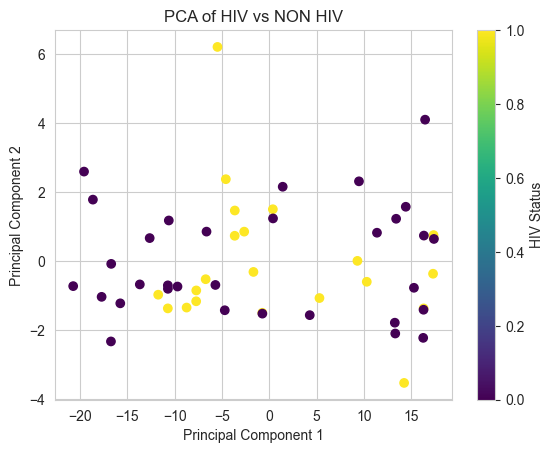

In [ ]:
#6.1.1 MIND Study -- ANCOVA Analysis

#Imports above were giving me errors, potentially from the conda environment -- had to reimport but not necessary

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#import ancova library
import statsmodels.formula.api as smf

#ANCOVA : TEPS as dependent, between HIV+/-, covariates age, race, total_scale_sc
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

##################################################################
#create continuous and categorical measures, done so that we can scale the data, as well as control the engineering of the categorical values

measures_continuous  = ['pc','pegoverallscore', 'madrs', 'bdi_score',  'cupit','DFAQ','teps' ,'shaps_totalscore','wbc','hematocrit','thyroid_stimulating_hormone','cd4_cd8_ratio']
measures_categorical = ['age', 'hiv_status']

##################################################################
#replace any 0 values in age with NaN, and drop any rows with NaN values

df_um_mind['age'] = df_um_mind['age'].replace(0,np.nan)
df_um_mind.dropna(inplace=True)

##################################################################
print('_______________________________VIF Analysis___________________________________')
#scale the continuous data, omit categorical and append after

scaler = StandardScaler()
X = df_um_mind[measures_categorical + measures_continuous]
Xscaled = X

#scale the data, omit categorical
Xscaled[measures_continuous] = scaler.fit_transform(X[measures_continuous])

# Ensure all columns in Xscaled are numeric
Xscaled = Xscaled.apply(pd.to_numeric, errors='coerce')

# Drop any rows with NaN values
Xscaled = Xscaled.dropna()

# Calculate VIF -- Useful for checking multicollinearity that can confound the ANCOVA

vif_data = [variance_inflation_factor(Xscaled.values, i) for i in range(Xscaled.shape[1])]
vif_df = pd.DataFrame({'Feature': Xscaled.columns, 'VIF': vif_data})

# Remove features with VIF > 10
print(vif_df)

################################################################## 
print('_______________________________Correlation Matrix___________________________________')

#create a correlation matrix to investigate potential correlations
X = X.apply(pd.to_numeric, errors='coerce')

corr_df, p_df = pearsoncorrelationmatrix(X)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', xticklabels=corr_df.columns, yticklabels=corr_df.columns)
plt.title('Correlation Matrix with Pearson r values')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(p_df, annot=True, cmap='coolwarm', xticklabels=p_df.columns, yticklabels=p_df.columns)
plt.title('Correlation Matrix with p-values')
plt.show()


################################################################
print('_______________________________PCA Analysis___________________________________')
#Just for fun, run a PCA analysis of the continuous variables between HIV+ and HIV- subjects

#Run a PCA analysis of HIV vs NON HIV
Xpca = Xscaled.drop(columns='hiv_status')

pca = PCA(n_components=2)
Xpca = pca.fit_transform(Xscaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PCA components:\n", pca.components_)

#graph the principal components
plt.figure()
plt.scatter(Xpca[:,0], Xpca[:,1], c=df_um_mind['hiv_status'], cmap='viridis')
plt.colorbar(label='HIV Status')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of HIV vs NON HIV')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   teps   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.8606
Date:                Mon, 07 Apr 2025   Prob (F-statistic):              0.566
Time:                        15:43:14   Log-Likelihood:                -229.15
No. Observations:                  54   AIC:                             478.3
Df Residuals:                      44   BIC:                             498.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/opt/anaconda3/envs/datascience/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
/opt/anaconda3/envs/datascience/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
/opt/anaconda3/envs/datascience/lib/python3.12/site-packages/statsmodels/base/model.py:1923: RuntimeWarning: invalid value encountered in divide


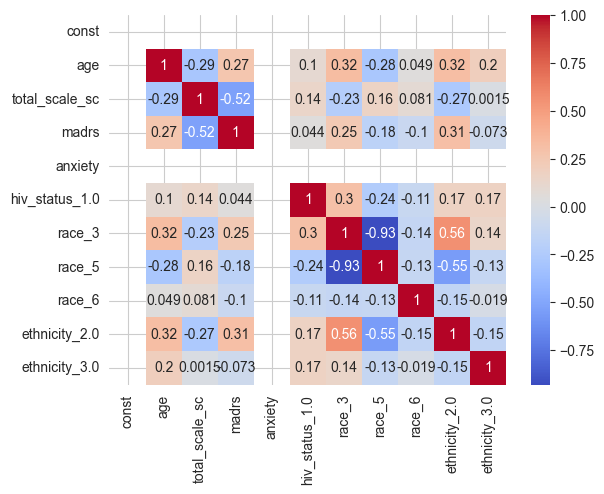

In [9]:
#6.1.2 ANCOVA Analysis Continued 


#Create X and y groups
y = df_um_mind['teps']
X = df_um_mind[['hiv_status', 'age', 'race', 'ethnicity', 'total_scale_sc', 'madrs', 'anxiety']]

# Convert categorical variables to numeric using one-hot encoding
X = pd.get_dummies(X, columns=['hiv_status', 'race', 'ethnicity'], drop_first=True).astype(int)

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Add an intercept constant column
X = sm.add_constant(X)

# Drop the indices to 
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Fit the model
model_interaction = smf.ols('teps ~ C(hiv_status) * age + race + ethnicity + total_scale_sc + madrs + anxiety', data=df_um_mind).fit()

# Print the summary
print(model_interaction.summary())
anova_table_interaction = sm.stats.anova_lm(model_interaction, typ=2)
print(anova_table_interaction)

#graph a correlation matrix of all the variables in the model
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()


T-Test: Group comparisons of HIV +/- individuals and shaps_totalscore
T-statistic: nan, p-value: nan
T-Test: Group comparisons of HIV +/- individuals and ucla
T-statistic: 1.9800284559039172, p-value: 0.05105446784644448
T-Test: Group comparisons of HIV +/- individuals and ira
T-statistic: 1.5387164031213567, p-value: 0.1277236566063056
T-Test: Group comparisons of HIV +/- individuals and cupit
T-statistic: -3.3931810638410558, p-value: 0.0010661100460389358


/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_85625/3535545952.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_85625/3535545952.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_85625/3535545952.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_85625/3535545952.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

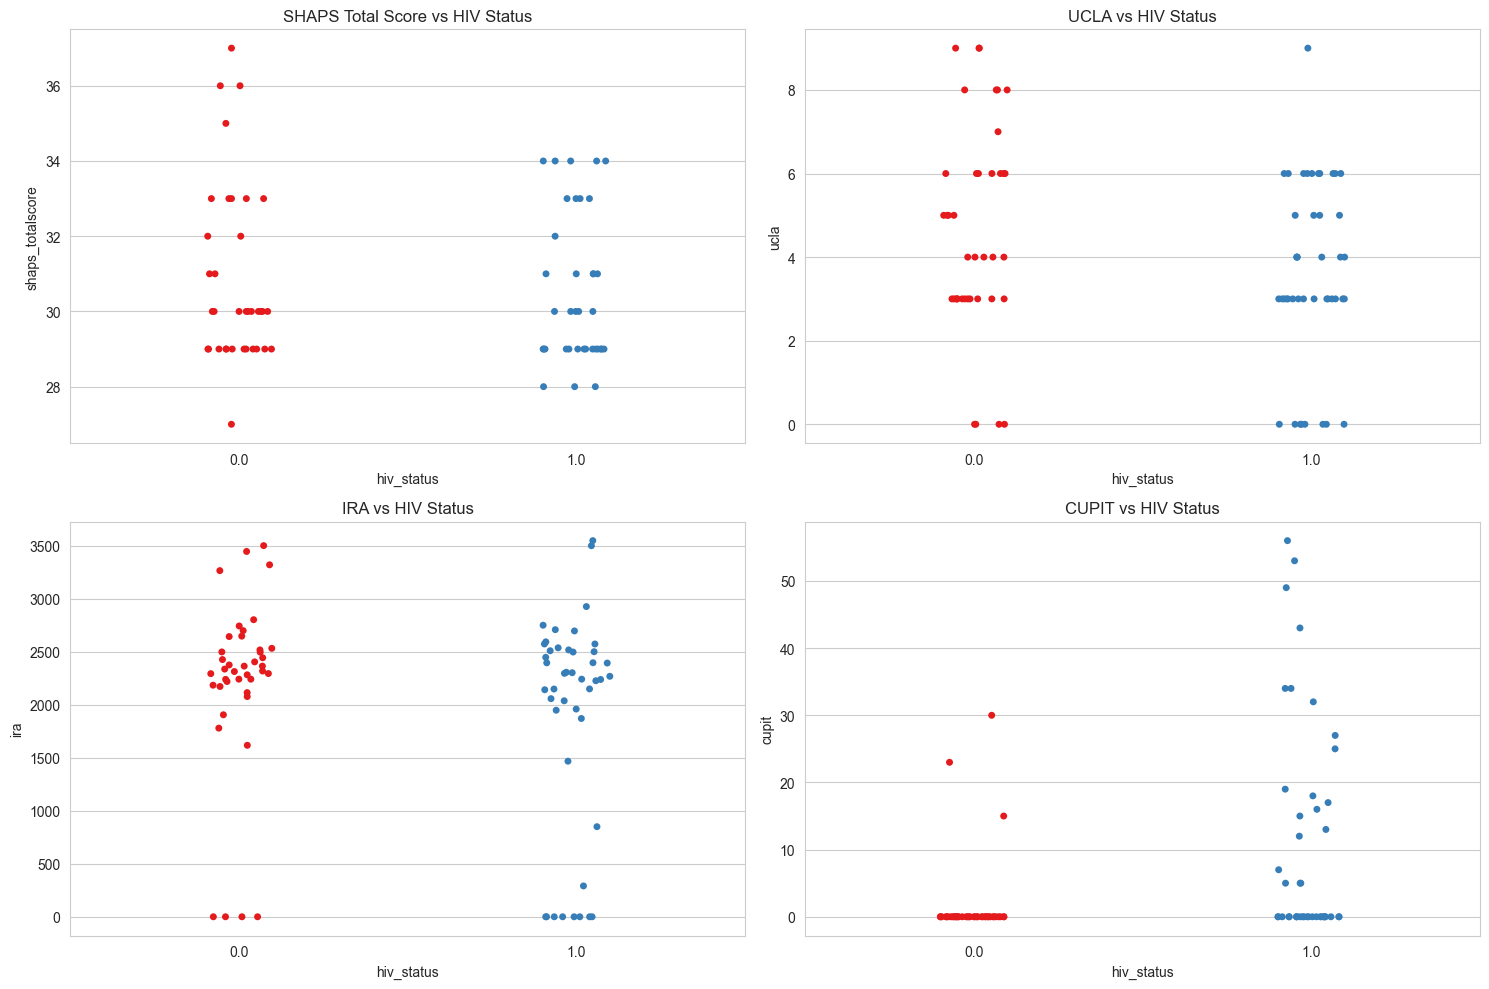

social support vs teps
Pearson r: 0.3475846551641375, p-value: 0.005639021844491164
social support vs madrs
Pearson r: -0.43578447517185465, p-value: 0.0003997330001250495
social support vs shaps
Pearson r: -0.08864213138093147, p-value: 0.4932713779688671
************************************************
social support vs teps in HIV+
Pearson r: 0.5468394517706456, p-value: 0.002602623404074827
social support vs teps in HIV-
Pearson r: 0.18332720012679637, p-value: 0.2993555450695041
************************************************
social support vs madrs in HIV+
Pearson r: -0.12292640759762505, p-value: 0.5331662960375462
social support vs madrs in HIV-
Pearson r: -0.6653839324953248, p-value: 1.757945608515061e-05

************************************************
T-Test: Social Support between HIV+ and HIV-
T-statistic: 0.6989723269051866, p-value: 0.48727005732680895

************************************************
T-Test: TEPS scores between HIV+ and HIV-
T-statistic: -0.270822460

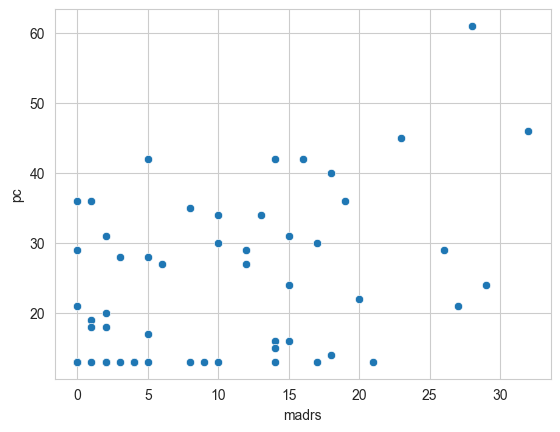

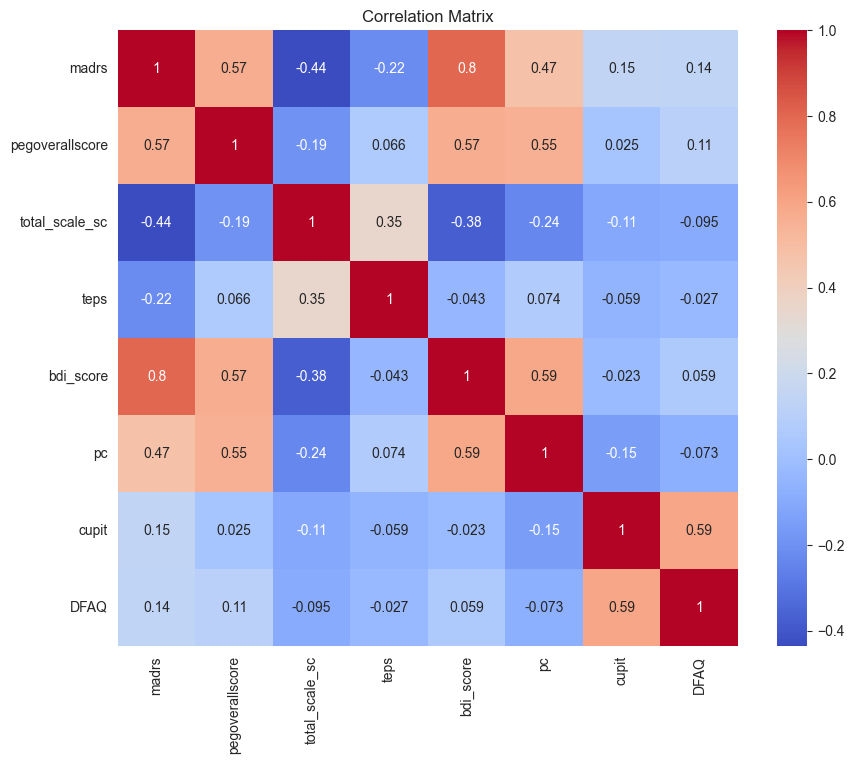

In [11]:
#6.5:MIND: Run basic statistics regarding HIV status and selected parameters for MIND


# Initialize the figure outside the loop
plt.figure(figsize=(15, 10))

variables = ['shaps_totalscore', 'ucla','ira', 'cupit']
titles = ['SHAPS Total Score vs HIV Status', 'UCLA vs HIV Status', 'IRA vs HIV Status', 'CUPIT vs HIV Status']

# Loop through the variables and perform t-test and plotting
for idx, var in enumerate(variables):


    # Perform t-test for HIV status and each continuous variable
    t_stat, p_value = stats.ttest_ind(df_um[df_um['hiv_status'] == 0][var], df_um[df_um['hiv_status'] == 1][var])
    print(f"T-Test: Group comparisons of HIV +/- individuals and {var}")
    print(f"T-statistic: {t_stat}, p-value: {p_value}")
    
    # Create strip plot in the appropriate subplot
    plt.subplot(2, 2, idx + 1)
    sns.stripplot(x='hiv_status', y=var, data=df_um, jitter=True, palette='Set1')
    plt.title(titles[idx])

# Adjust layout and show the figure after the loop
plt.tight_layout()
plt.show()

#create a scatterplot graph showing sc total with teps
plt.show()
sns.scatterplot(x='madrs', y='pc', data=df_um_mind)



#For CPR Abstract: What is the effects of percieved social support and hiv on anhedonia?

#is social support negatively correlated with anhedonia
#dependent: depression/anhedonia(teps)
#independent: social support (total_scale_sc, madrs)

df_um_mind = df_um.dropna()
X = df_um_mind[['total_scale_sc', 'madrs']]
y = df_um_mind['teps']


#scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add a constant term to the predictor
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()
#print(model.summary())


#is the social support scale (total_scale_sc) and anhedonia(teps) related?
#PEARSON R CORRELATION: Is teps correlated with social support?
pearson_r, p_value = stats.pearsonr(df_um_mind['total_scale_sc'], df_um_mind['teps'])
print('social support vs teps')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


#is the social support scale (total_scale_sc) and depression(madrs) related?
#PEARSON R CORRELATION: Is teps correlated with madrs?
pearson_r, p_value = stats.pearsonr(df_um_mind['total_scale_sc'], df_um_mind['madrs'])
print('social support vs madrs')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

#PEARSON R CORRELATION: Is teps correlated with shaps?
pearson_r, p_value = stats.pearsonr(df_um_mind['total_scale_sc'], df_um_mind['shaps_totalscore'])
print('social support vs shaps')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

#Finding correlative differences between two groups 
#Between HIV positive and HIV negative; find 
df_mind_pos = df_um_mind[df_um_mind['hiv_status'] == 1]
df_mind_neg = df_um_mind[df_um_mind['hiv_status'] == 0]

print('************************************************')
#is the social support scale (total_scale_sc) and anhedonia(teps) related?
#PEARSON R CORRELATION: Is teps correlated with social support?
pearson_r, p_value = stats.pearsonr(df_mind_pos['total_scale_sc'], df_mind_pos['teps'])
print('social support vs teps in HIV+')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_mind_neg['total_scale_sc'], df_mind_neg['teps'])
print('social support vs teps in HIV-')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")



print('************************************************')
#is the social support scale (total_scale_sc) and depression(madrs) related?
#PEARSON R CORRELATION: Is teps correlated with social support?
pearson_r, p_value = stats.pearsonr(df_mind_pos['total_scale_sc'], df_mind_pos['madrs'])
print('social support vs madrs in HIV+')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_mind_neg['total_scale_sc'], df_mind_neg['madrs'])
print('social support vs madrs in HIV-')
print(f"Pearson r: {pearson_r}, p-value: {p_value}\n")

print('************************************************')


#T-TEST: Is there a significant difference in social support between HIV+ and HIV- individuals?
t_stat, p_value = stats.ttest_ind(df_mind_pos['total_scale_sc'], df_mind_neg['total_scale_sc'])
print('T-Test: Social Support between HIV+ and HIV-')
print(f"T-statistic: {t_stat}, p-value: {p_value}\n")


print('************************************************')

#T-TEST: Is there a significant difference in social support between HIV+ and HIV- individuals?
t_stat, p_value = stats.ttest_ind(df_mind_pos['teps'], df_mind_neg['teps'])
print('T-Test: TEPS scores between HIV+ and HIV-')
print(f"T-statistic: {t_stat}, p-value: {p_value}\n")



#create a correlation matrix of all above variables, include p values
corr_matrix = df_um_mind[['madrs','pegoverallscore','total_scale_sc','teps','bdi_score','pc','cupit','DFAQ']].corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title('Correlation Matrix')
plt.show()



In [16]:
#7: Concatenate a df with ecom+UM data for Candie participants

df_united = pd.concat([df_ecom, df_um_candie])

#missing some value, drop any missing bdi_score
df_united = df_united.dropna(subset=['bdi_score','teps','pegoverallscore'])


#7.5: Run analyses to identify trends within the combined data

#plot it out 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='madrs', y='pegoverallscore', data=df_united)
plt.title('madrs vs pegoverallscore')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='madrs', y='pc', data=df_united)
plt.title('madrs vs pain catastrophizing')
plt.show()


print('************************************************')

#First, are the dependent variables correlated?
pearson_r, p_value = stats.pearsonr(df_united['pegoverallscore'], df_united['pc'])
print('DEPENDENT: pegoverall vs sc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


#OLS MODEL USING  MULTIPLE LINEAR REGRESSION: Studying the pc score
xvar = ['cupit','bdi_score','DFAQ','teps','shaps_totalscore','anxiety']
X = df_united[xvar]
y = df_united['pc']


# Scale data, keep column names
# Run an OLS estimate on all values compared to pc, keep index
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=xvar)

# Reset the indices of X and y to ensure they are aligned
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X = sm.add_constant(X)
model1 = sm.OLS(y, X).fit()
print(model1.summary())


print('______________________________________Pearson R Tests_____________________________________________\n')

pearson_r, p_value = stats.pearsonr(df_united['madrs'], df_united['pc'])
print('madrs vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('__________________________________________________________________________________________________\n')

pearson_r, p_value = stats.pearsonr(df_united['bdi_score'], df_united['pc'])
print('bdi vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('__________________________________________________________________________________________________\n')

earson_r, p_value = stats.pearsonr(df_united['madrs'], df_united['pegoverallscore'])
print('madrs vs pegoverallscore')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('__________________________________________________________________________________________________\n')

pearson_r, p_value = stats.pearsonr(df_united['bdi_score'], df_united['pegoverallscore'])
print('bdi vs pegoverallscore')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('__________________________________________________________________________________________________\n')

pearson_r, p_value = stats.pearsonr(df_united['teps'], df_united['madrs'])
print('teps vs madrs')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['teps'], df_united['bdi_score'])
print('teps vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('__________________________________________________________________________________________________\n')

pearson_r, p_value = stats.pearsonr(df_united['cupit'], df_united['madrs'])
print('cupit vs madrs')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")





#create a correlation matrix of all above variables, include p values
corr_matrix = df_united[['madrs','pegoverallscore','bdi_score','pc','cupit','anxiety']].corr()

# Create a heatmap to visualize the correlation matrix
#include p values as well
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title('Correlation Matrix')
plt.show()







NameError: name 'df_ecom' is not defined

In [20]:
#EXTRA TESTS - Exploratory Analyses
#PEARSON R CORRELATION: Is PEGPAIN associated w/bdi or teps?
pearson_r, p_value = stats.pearsonr(df_united['pegoverallscore'], df_united['teps'])
print('pegpain vs teps')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['pegoverallscore'], df_united['bdi_score'])
print('pegpain vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


print('************************************************')


#PEARSON R CORRELATION: Is PC scale associated w/bdi or teps?
pearson_r, p_value = stats.pearsonr(df_united['pc'], df_united['teps'])
print('pc vs teps')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['pc'], df_united['bdi_score'])
print('pc vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


print('************************************************')


#PEARSON R CORRELATION: Is cupit scale associated w/bdi or teps?
pearson_r, p_value = stats.pearsonr(df_united['cupit'], df_united['teps'])
print('cupit vs teps')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['cupit'], df_united['bdi_score'])
print('cupit vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

#To add onto the above is cupit associated with either pain scale
pearson_r, p_value = stats.pearsonr(df_united['cupit'], df_united['pegoverallscore'])
print('cupit vs pegpain')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['cupit'], df_united['pc'])
print('cupit vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


print('************************************************')
pearson_r, p_value = stats.pearsonr(df_united['madrs'], df_united['pc'])
print('madrs vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")


pearson_r, p_value = stats.pearsonr(df_united['madrs'], df_united['pegoverallscore'])
print('madrs vs pegpain')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['madrs'], df_united['bdi_score'])
print('madrs vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('************************************************')
pearson_r, p_value = stats.pearsonr(df_united['DFAQ'], df_united['pc'])
print('DFAQ vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['DFAQ'], df_united['pegoverallscore'])
print('DFAQ vs pegpain')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['DFAQ'], df_united['bdi_score'])
print('DFAQ vs bdi')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

print('************************************************')

pearson_r, p_value = stats.pearsonr(df_united['shaps_totalscore'], df_united['pc'])
print('shaps vs pc')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")

pearson_r, p_value = stats.pearsonr(df_united['shaps_totalscore'], df_united['pegoverallscore'])
print('shaps vs pegpain')
print(f"Pearson r: {pearson_r}, p-value: {p_value}")



NameError: name 'df_united' is not defined

In [20]:
#8: CFAR ABSTRACT -- Concatenate datasets to analyze, including lab tests

#load respective redcaps -- deidentified
umredcap = pd.read_csv('RedcapAbstract/MiamiRedcapUSETHIS.csv')
ecomredcap = pd.read_csv('RedcapAbstract/ecomRedcapUSETHIS.csv')


surveys  = ['record_id','ed3', 'age','race', 'pc','pegoverallscore', 'madrs', 'bdi_score','anxiety','teps','cupit']
labs     = ['delta_9_thc','wbc','crp','cd4','cd8','cd4_cd8_ratio','hiv_1_viral_rna']

#measures we want
measures = surveys + labs

#################################### REMOVE THIS
df_um   = redcap_clean(umredcap, measures)
df_ecom = redcap_clean(ecomredcap, measures)

#locate any participants that are dropped out from the study
dropout = [
    "BD2010", "BD2002", "BD2009", "BD2008", "BD2016", "BD2041", "BCD2026", 
    "BD2029", "BD2011", "BCD2048", "BD2057", "BCD2081", "BD2060", "BCD2051", 
    "BCD2044", "BCD2007", "BCD2091", "BCD2097", "BCD2073", "BD2074", "BD2059", 
    "BD2129", "BCD2107", "BD2082", "BCD2070", "BD2017", "C2138", "BD2069", 
    "C2095", "BCD2128", "BD2126", "BCD2147", "BD2119", "BCD2154", "BCD2079", 
    "BD2121", "C2151", "BD2122", "BCD2145", "BD2093", "BCD2156", "BCD2160", 
    "BCD2136", "BCD2034", "C2006", "BCD2166", "BD2152", "BD2167", "BCD2174", 
    "BCD2176"
]


dropout = ['BD2010','BD2002','BD2009','BD2008','BD2016','BD2041','BCD2026','BD2029','BD2011','BCD2048','BD2057','BCD2081','BD2060','BCD2051','BCD2044','BCD2007','BCD2091','BCD2097','BCD2073','BD2074','BD2059','BD2129','BCD2107','BD2082','BCD2070','BD2017','C2138','BD2069','C2095','BCD2128','BD2126','BCD2147','BD2119','BCD2154','BCD2079','BD2121','C2151','BD2122','BCD2145','BD2093','BCD2156','BCD2160','BCD2136','BCD2034','C2006','BCD2166']
df_um = df_um[~df_um['record_id'].isin(dropout)]

df_um.drop_duplicates(subset= 'record_id', inplace = True)
df_ecom = df_ecom[~df_ecom['record_id'].isin(dropout)]

#add together the datasets, drop follow up visits
df_united = pd.concat([df_ecom, df_um])


df_united.drop_duplicates(subset = 'record_id', inplace = True)
df_united = df_united[~df_united['record_id'].isin(dropout)]

#drop problem subjects
#if any column contains 'Not Completed By Lab' drop it
df_united= df_united.replace(str('Target Not Detected'), 0)
df_united = df_united[~df_united['record_id'].isin(['BCD1012','B1052'])]

#capitalize all record ID
df_united['record_id'] = df_united['record_id'].str.upper()
df_united = df_united.iloc[3:].reset_index(drop=True)
df_united = df_united[~df_united['record_id'].str.contains('TEST', na=False)]

# Drop any record that is equal to any number from 4 to 10
df_united = df_united[~df_united['record_id'].isin(map(str, range(4, 11)))]

#reset index for later
df_united = df_united.reset_index(drop=True)

#initialize HIV column
df_united['hiv'] = 0

#create a column based on study status VL - ALL are HIV+
for i in range(len(df_united)):
    if pd.isna(df_united['hiv_1_viral_rna'].iloc[i]):
        df_united.loc[i, 'hiv'] = 0
    else:
        df_united.loc[i, 'hiv'] = 1


#impute missing ages by using variance of current age
#first change all zeros to nan
df_united['age'] = df_united['age'].replace(0, np.nan)

# Calculate the mean and variance of the age column
mean_age = df_united['age'].mean()
variance_age = df_united['age'].var()

# Generate random noise based on the variance
random_noise = np.random.normal(0, np.sqrt(variance_age), size=df_united['age'].isnull().sum())

# Impute missing ages with the mean age plus random noise
df_united.loc[df_united['age'].isnull(), 'age'] = mean_age + random_noise

#many of these labs are missing wbc, one of the mandatory tests as well as others 
df_united = df_united.dropna(subset = 'wbc')

#engineer the Viral Load columns for further analysis
corr_matrix = df_united[['madrs','anxiety','bdi_score','pc','hiv_1_viral_rna']]
corr_matrix.dropna(inplace=True)

# Replace 'Target Not Detected' with 0 and '<20' with 10 in the 'hiv_1_viral_rna' column
corr_matrix['hiv_1_viral_rna'] = corr_matrix['hiv_1_viral_rna'].replace({'Target not Detected': 0, '<20': 10})
# Remove commas from the 'hiv_1_viral_rna' column and convert to integer
# Remove commas from the 'hiv_1_viral_rna' column and convert to integer
corr_matrix['hiv_1_viral_rna'] = corr_matrix['hiv_1_viral_rna'].str.replace(',', '').fillna(0).astype(int)

measures_we_care_about = ['madrs','anxiety','bdi_score','pc','hiv_1_viral_rna']
corr_matrix = df_united[['madrs','anxiety','bdi_score','pc','hiv_1_viral_rna']]

corr_matrix.dropna(inplace=True)

df_united_candie = df_united[df_united['record_id'].str.contains('C')]


#DEMOGRAPHIC DATA
groups = pd.DataFrame(columns=['hivpos_dep','hivpos_nondep','hivneg_dep','hivneg_nondep'])

groups[hivpos_dep]    = df_united.loc[(df_united['hiv'] == 1) & (df_united['madrs'] >= 12)].shape[0]
groups[hivpos_nondep] = df_united.loc[(df_united['hiv'] == 1) & (df_united['madrs'] < 12)].shape[0]
groups[hivneg_dep]    = df_united.loc[(df_united['hiv'] == 0) & (df_united['madrs'] >= 12)].shape[0]
groups[hivneg_nondep] = df_united.loc[(df_united['hiv'] == 0) & (df_united['madrs'] < 12)].shape[0]


print(groups)

Empty DataFrame
Columns: [hivpos_dep, hivpos_nondep, hivneg_dep, hivneg_nondep, 28, 41, 22, 27]
Index: []


/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/1386326886.py:95: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/1386326886.py:95: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/3785642051.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/3785642051.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

In [21]:
#CFAR: T-Tests

#HIV GROUPS


df_hivpos = df_united[df_united.hiv==1]
df_hivneg = df_united[df_united.hiv==0]

# Force the 'hiv' column to be integer
df_hivpos['hiv'] = df_hivpos['hiv'].astype(int)
df_hivneg['hiv'] = df_hivneg['hiv'].astype(int)

#same thing tbh
measures_we_care_about  = ['madrs','pc','bdi_score','pegoverallscore','anxiety','teps']

df1  = df_united[['hiv'] + measures_we_care_about]
df1  = df1.dropna()

print('______________________________________________________________________________________________________________________________')

for i in measures_we_care_about:
    
    #t-test loop
    t_stat, p_value = stats.ttest_ind(df_hivpos[i].dropna(), df_hivneg[i].dropna())
    print(f"T-Test: {i} between HIV+ and HIV-")
    print(f"T-statistic: {t_stat}, p-value: {p_value}\n")

    print('__________________________________________________________________________')

print('__________________________________________________________________________')
print('__________________________________________________________________________')
print('__________________________________________________________________________')

for i in measures_we_care_about:
    
    #Point-Biserial Correlation
    print(f"H1: Is there a correlation between HIV status and {i}")

    corr, p_value = stats.pointbiserialr(df1['hiv'], df1[i])
    print(f"Point-Biserial Correlation: {corr}")
    print(f"P-value: {p_value}\n")

    print('__________________________________________________________________________')





#OLS Multiple Linear regression investigating relationship between variables and PC

#organize and scale data
measures_we_care_about  = ['bdi_score','anxiety','teps']

scaler = StandardScaler()

#create dep/indy 
y = df1['pc']
X = df1[['hiv'] + measures_we_care_about]



##################################################################

measures_we_care_about  = ['bdi_score','anxiety','teps']

Xscaled = df1[['hiv'] + measures_we_care_about]
Xscaled[measures_we_care_about] = scaler.fit_transform(X[measures_we_care_about])


#Utilize VIF to test for any multicolinearity issues
vif_data = pd.DataFrame()
vif_data['Feature'] = Xscaled.columns
vif_data['VIF'] = [variance_inflation_factor(Xscaled.values, i) for i in range(Xscaled.shape[1])]

# Display the VIF values
print(vif_data)

#now try adding the interaction term
for i in measures_we_care_about:
    Xscaled[f'hiv_{i}'] = X['hiv'] * X[i]

# Add intercept term
Xscaled = sm.add_constant(Xscaled)

#fit the model!
model = sm.OLS(y, Xscaled).fit()
print(model.summary())


#now that we know that hiv and bdi have signifigant effects on pc, lets check correlations above
#create mediation matrix
# Include 'pc' in the DataFrame X
X['pc'] = df1['pc']

mediationmatrix   = X[['hiv','bdi_score','pc']]

#scale all values together
mediationmatrix[['bdi_score','pc']]= scaler.fit_transform(mediationmatrix[['bdi_score','pc']])

#add a constant
mediationmatrix = sm.add_constant(mediationmatrix)

# Mediation analysis: hiv -> bdi_score -> pc
mediation_results = pg.mediation_analysis(data=mediationmatrix, x='bdi_score', m='hiv', y='pc')

# Display the results
print(mediation_results)


print('______________________________________________________________________________')


#1) Mediating analysis: PCS, BDI and CUPIT
measures = ['pc','bdi_score','cupit']
mediationmatrix  = df_united_candie[measures].dropna()

mediationmatrix = pd.DataFrame(scaler.fit_transform(mediationmatrix), columns=mediationmatrix.columns)

#add a constant
mediationmatrix = sm.add_constant(mediationmatrix)

# Mediation analysis: hiv -> bdi_score -> pc
mediation_results = pg.mediation_analysis(data=mediationmatrix, x='bdi_score', m='cupit', y='pc')

# Display the results
print(mediation_results)



/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/2497943725.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/2497943725.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/nc/1mn73j_x26v5cvzpnmq5vnyh0000gp/T/ipykernel_88671/2497943725.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

______________________________________________________________________________________________________________________________
T-Test: madrs between HIV+ and HIV-
T-statistic: -0.4670567814304245, p-value: 0.6413353539719441

__________________________________________________________________________
T-Test: pc between HIV+ and HIV-
T-statistic: -2.3770788180706077, p-value: 0.01908665259761641

__________________________________________________________________________
T-Test: bdi_score between HIV+ and HIV-
T-statistic: 0.8659470182492185, p-value: 0.3883540694307068

__________________________________________________________________________
T-Test: pegoverallscore between HIV+ and HIV-
T-statistic: -1.0750879981770565, p-value: 0.28473128519153507

__________________________________________________________________________
T-Test: anxiety between HIV+ and HIV-
T-statistic: 0.5679445996581121, p-value: 0.5711702726756424

_________________________________________________________________

Explained variance ratio: [0.36397612 0.15198942 0.11436507 0.10425448 0.09478981 0.06305398]


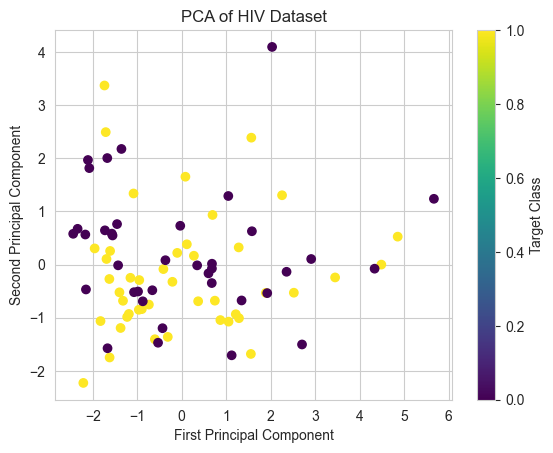

In [58]:
#_________________________________________Extras: Exploratory Analysis______________________________________________________

#TEST: Try a k means clustering to see if there is any identifiable trends in hiv's PCs

labs  = ['wbc','crp','cd4_cd8_ratio']

xvars = ['pc','pegoverallscore', 'madrs', 'bdi_score', 'anxiety','teps']
xvars = xvars + labs

#create df with values we want 
df = df_united[['hiv'] + xvars]

# Ensure all columns in X are numeric and handle missing values
df = df.apply(pd.to_numeric, errors='coerce') 

#drop all missing values for PCA 
df = df.dropna()

# Assign DVs and IV
X = df[xvars]
y = df['hiv']

# Ensure y matches the updated indices of X
scaler = StandardScaler()


# Scale the data
X_scaled = scaler.fit_transform(X)


 # Reduce the data to 2 dimensions
pca = PCA(n_components=6) 
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA of HIV Dataset')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(label='Target Class')
plt.show()

#_____________________________________________________________________________________________________
